Loading: SPY
Loading: QQQ
Loading: IWM
Loading: EEM
Loading: EWJ
Loading: FXI
Loading: GLD
Loading: TLT
Loading: USO
Loading: BTC-USD
Loading: 069500
Loading: 091160
Loading: 091170
Loading: 091180
Loading: 102960
Loading: 102970
Loading: 117460
Loading: 117680
Loading: 117700
Loading: 122630
Loading: 139220
Loading: 139240
Loading: 139250
Loading: 139270
Loading: 140700
Loading: 140710
Loading: 147970
Loading: 157490
Loading: 161510
Loading: 227540
Loading: 228790
Loading: 228800
Loading: 228810
Loading: 229200
Loading: 244580
Loading: 261070
Loading: 266360
Loading: 266370
Loading: 266390
Loading: 266410
Loading: 266420
Loading: 300950
Loading: 305720
Loading: 307520
Loading: 364980
Loading: 364990
Loading: 365000
Loading: 000240
Loading: 000270
Loading: 000810
Loading: 001120
Loading: 001270
Loading: 001430
Loading: 002310
Loading: 003540
Loading: 003550
Loading: 003690
Loading: 004980
Loading: 005380
Loading: 005830
Loading: 005940
Loading: 007340
Loading: 009970
Loading: 011780
Lo

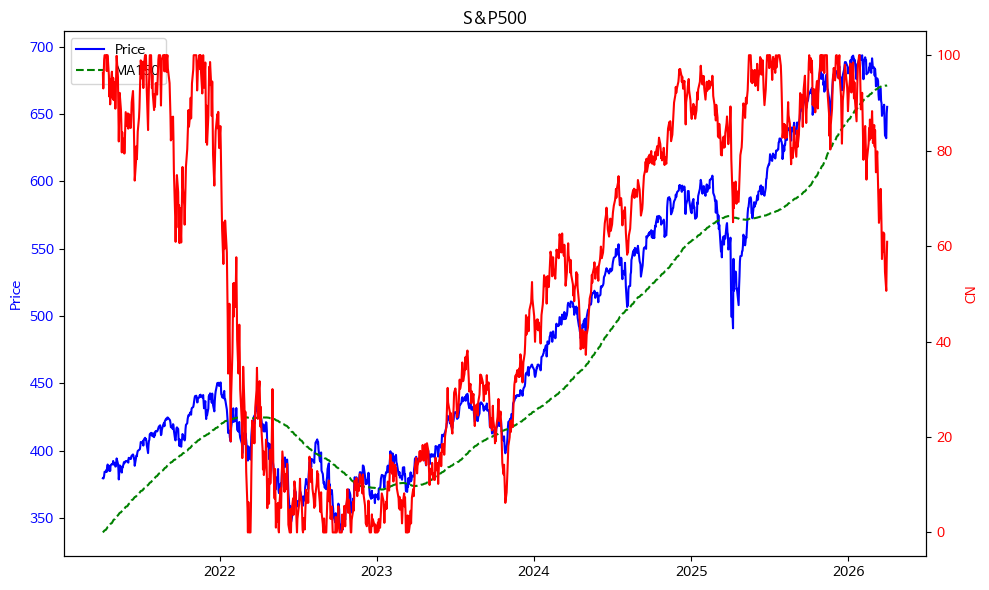

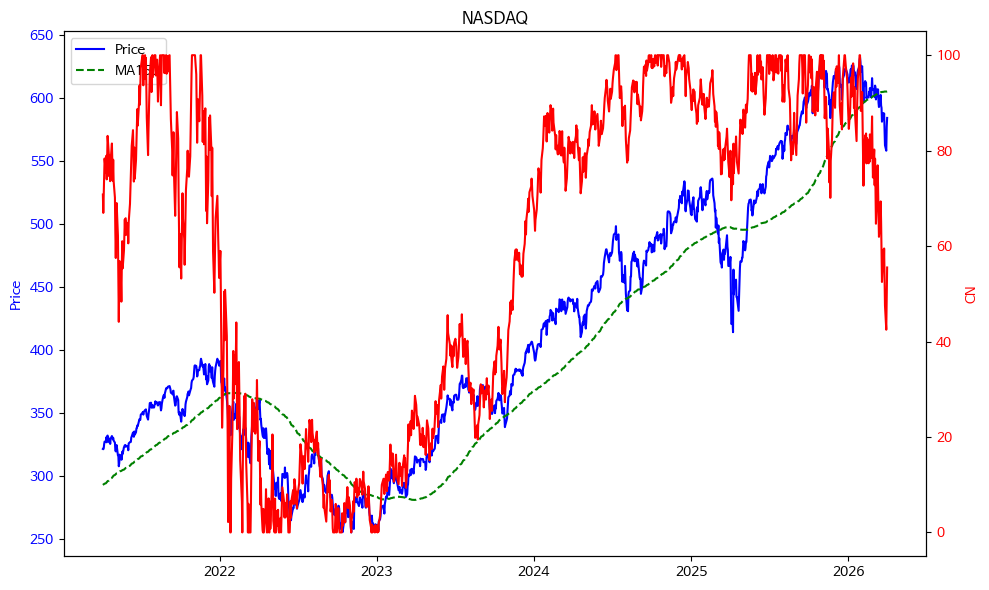

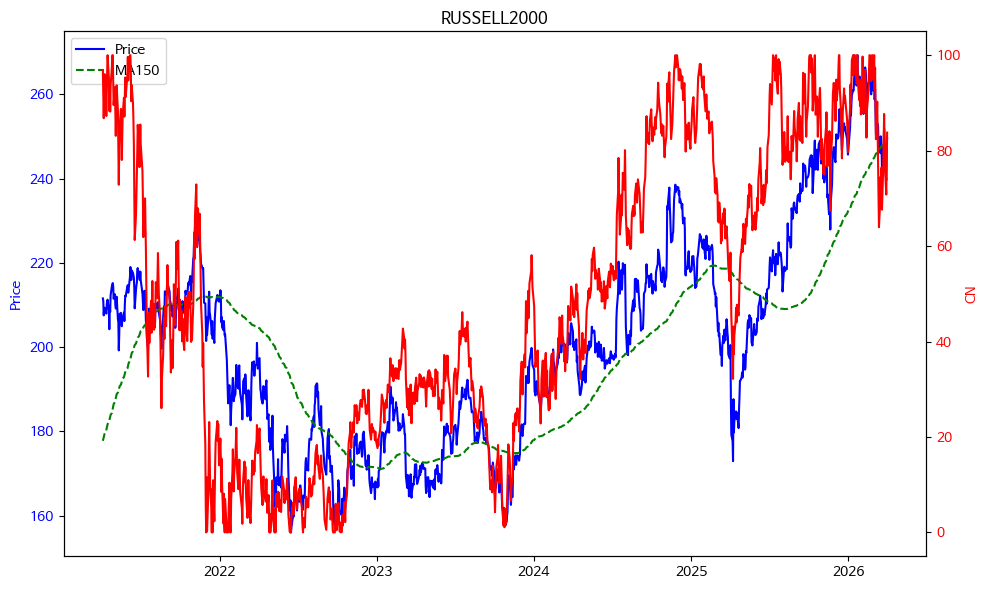

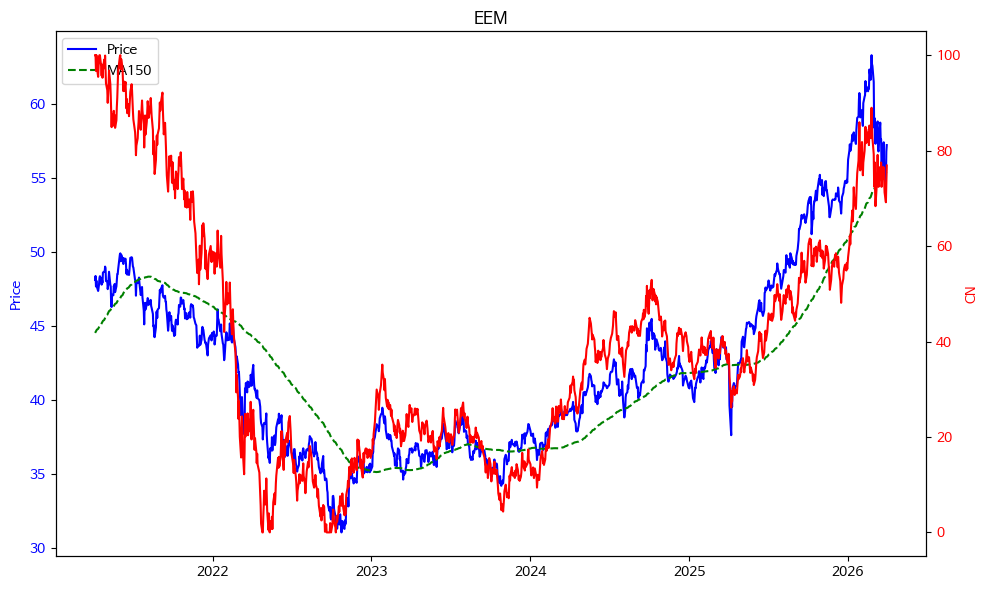

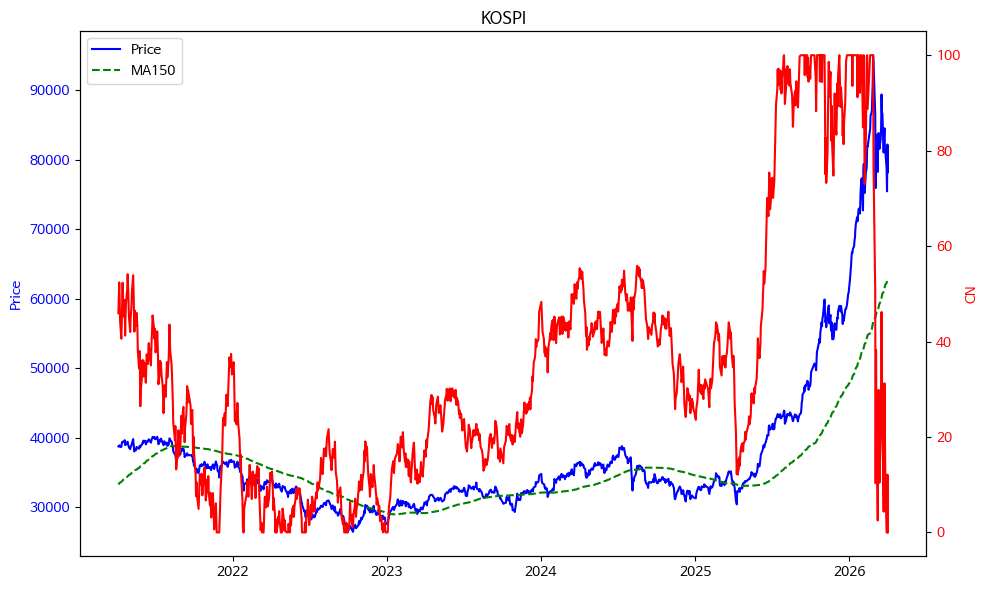

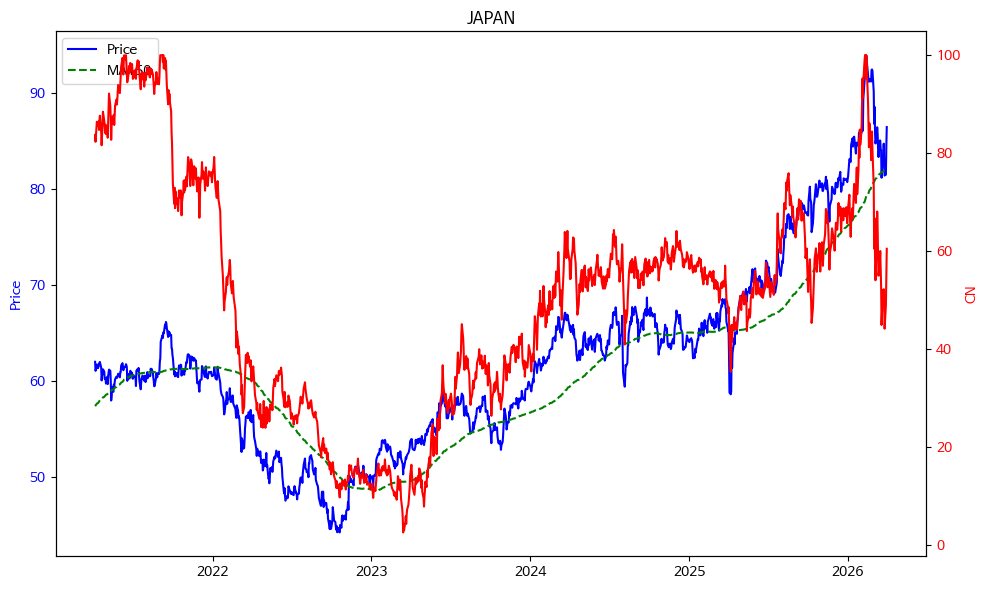

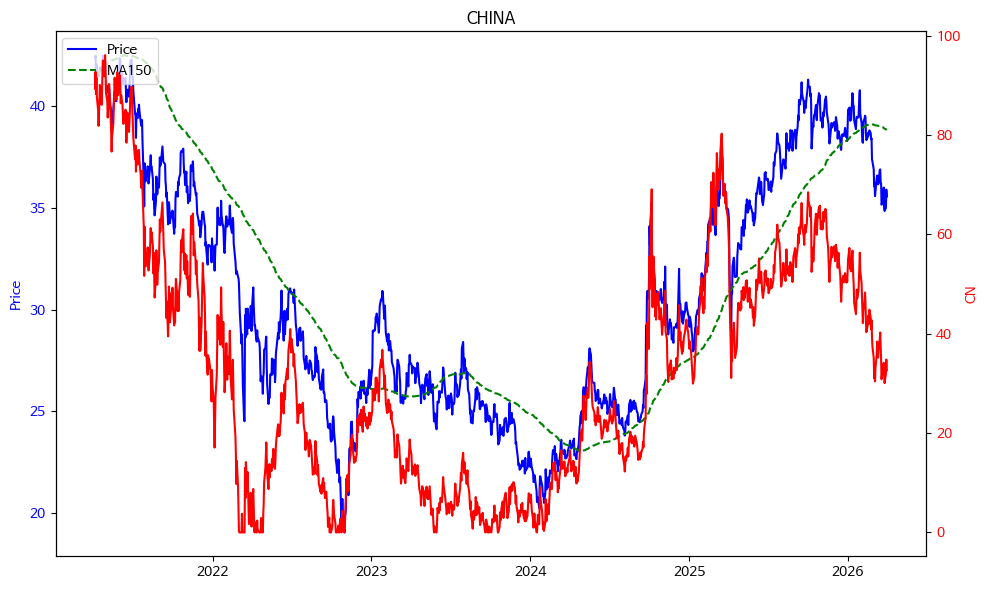

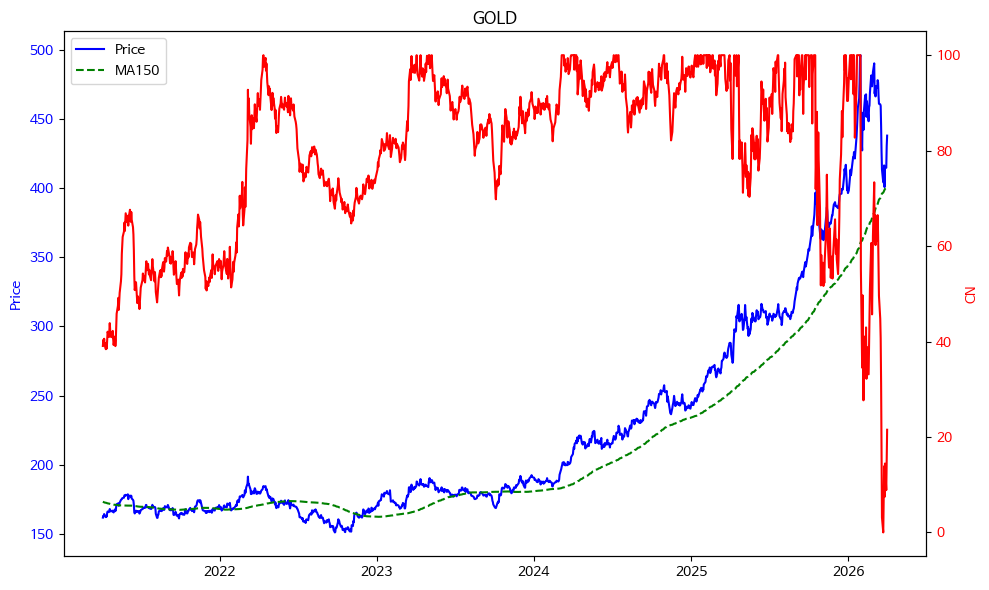

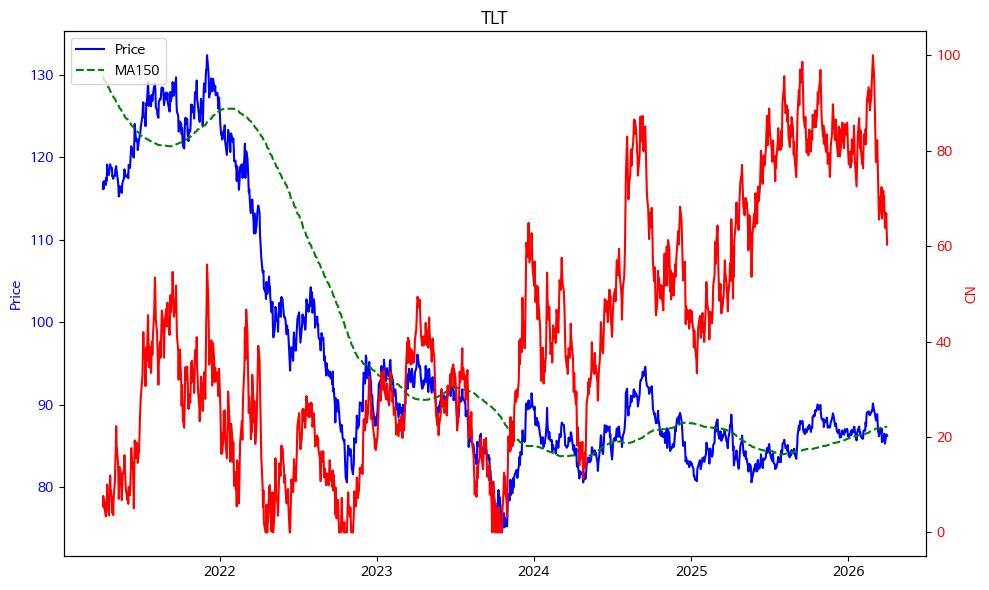

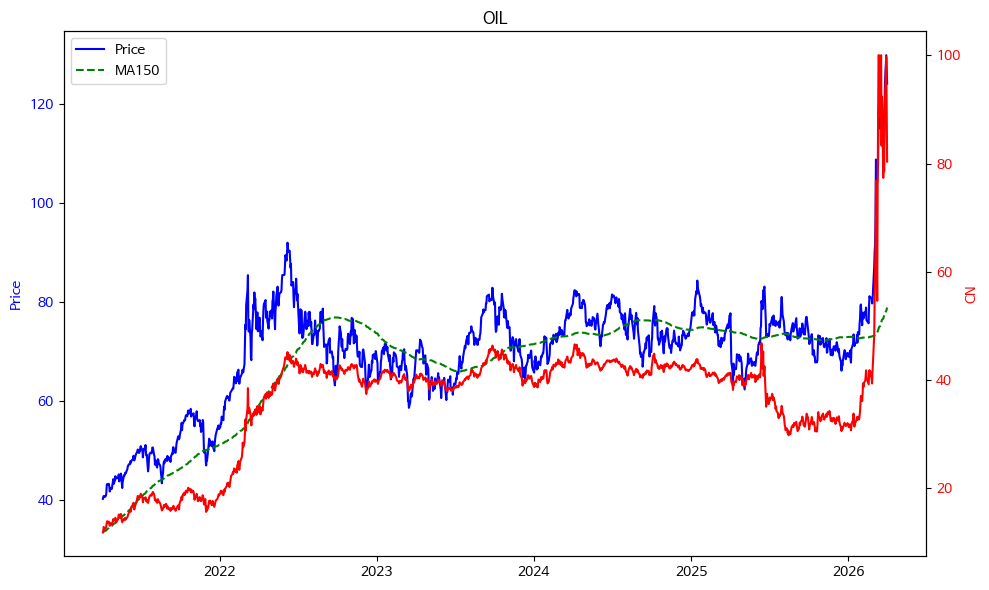

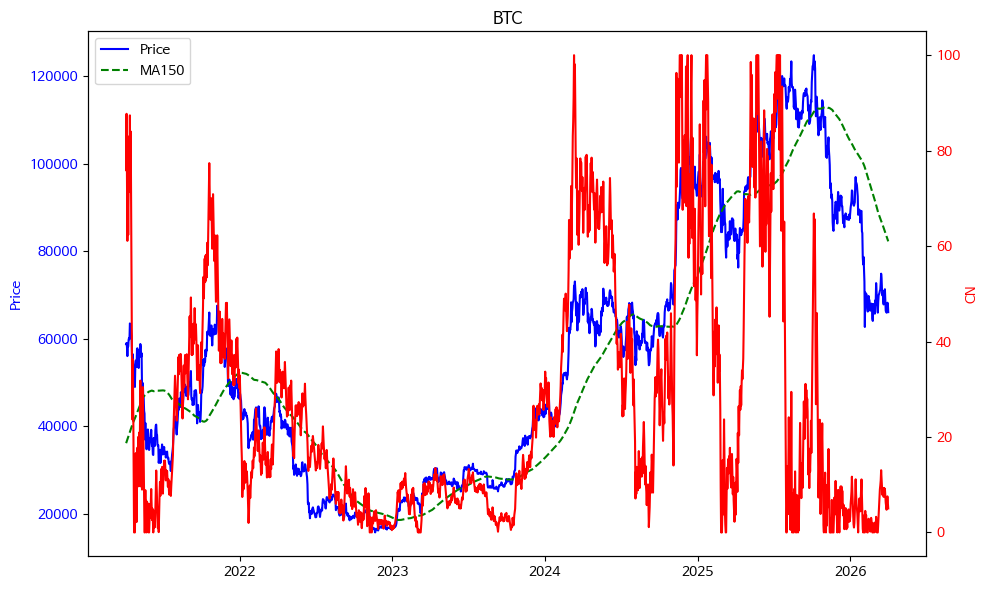

In [ ]:
import subprocess
subprocess.run(["pip", "install", "pykrx", "-q"], check=True)

import pandas as pd
import matplotlib.pyplot as plt
import datetime
import yfinance as yf
from pykrx import stock as krx
import numpy as np

# -----------------------------
# 분석 종목
# -----------------------------

# 글로벌 (yfinance)
global_tickers = {
    "SPY":       "S&P500",
    "QQQ":       "NASDAQ",
    "IWM":       "RUSSELL2000",
    "EEM":       "EEM",
    "EWJ":       "JAPAN",
    "FXI":       "CHINA",
    "GLD":       "GOLD",
    "TLT":       "TLT",
    "USO":       "OIL",
    "BTC-USD":   "BTC",
}

# 글로벌 중 한국 (pykrx)
kospi_global = {
    "069500": "KOSPI",
}

# 한국 ETF (pykrx) - 종목코드 6자리
etf_tickers = {
    "091160": "KODEX 반도체",
    "091170": "KODEX 은행",
    "091180": "KODEX 자동차",
    "102960": "KODEX 기계장비",
    "102970": "KODEX 증권",
    "117460": "KODEX 에너지화학",
    "117680": "KODEX 철강",
    "117700": "KODEX 건설",
    "122630": "KODEX 레버리지",
    "139220": "TIGER 200 건설",
    "139240": "TIGER 200 철강소재",
    "139250": "TIGER 200 에너지화학",
    "139270": "TIGER 200 금융",
    "140700": "KODEX 보험",
    "140710": "KODEX 운송",
    "147970": "TIGER 모멘텀",
    "157490": "TIGER 소프트웨어",
    "161510": "PLUS 고배당주",
    "227540": "TIGER 200 헬스케어",
    "228790": "TIGER 화장품",
    "228800": "TIGER 여행레저",
    "228810": "TIGER 미디어컨텐츠",
    "229200": "KODEX 코스닥150",
    "244580": "KODEX 바이오",
    "261070": "TIGER 코스닥150바이",
    "266360": "KODEX K콘텐츠",
    "266370": "KODEX IT",
    "266390": "KODEX 경기소비재",
    "266410": "KODEX 필수소비재",
    "266420": "KODEX 헬스케어",
    "300950": "KODEX 게임산업",
    "305720": "KODEX 2차전지산업",
    "307520": "TIGER 지주회사",
    "364980": "TIGER 2차전지TOP10",
    "364990": "TIGER 게임TOP10",
    "365000": "TIGER 인터넷TOP10",
}

# 코스피 종목 (pykrx)
kospi_tickers = {
    "000240": "한국앤컴퍼니",
    "000270": "기아",
    "000810": "삼성화재",
    "001120": "LX인터내셔널",
    "001270": "부국증권",
    "001430": "세아베스틸지주",
    "002310": "아세아제지",
    "003540": "대신증권",
    "003550": "LG",
    "003690": "코리안리",
    "004980": "성신양회",
    "005380": "현대차",
    "005830": "DB손해보험",
    "005940": "NH투자증권",
    "007340": "DN오토모티브",
    "009970": "영원무역홀딩스",
    "011780": "금호석유화학",
    "016360": "삼성증권",
    "017670": "SK텔레콤",
    "017800": "현대엘리베이터",
    "024110": "기업은행",
    "029780": "삼성카드",
    "030000": "제일기획",
    "030200": "KT",
    "032640": "LG유플러스",
    "032830": "삼성생명",
    "033780": "KT&G",
    "035250": "강원랜드",
    "036460": "한국가스공사",
    "055550": "신한지주",
    "071050": "한국금융지주",
    "078930": "GS",
    "086790": "하나금융지주",
    "105560": "KB금융",
    "138930": "BNK금융지주",
    "139130": "iM금융지주",
    "161390": "한국타이어앤테크놀로지",
    "175330": "JB금융지주",
    "183190": "아세아시멘트",
    "192080": "더블유게임즈",
    "214320": "이노션",
    "316140": "우리금융지주",
}

# -----------------------------
# 설정값
# -----------------------------
RECENTLY_CHANGED_DAYS = 7

# 글로벌 추세 분석 순서 (KOSPI 포함)
global_names_ordered = [
    "S&P500", "NASDAQ", "RUSSELL2000",
    "EEM", "KOSPI", "JAPAN", "CHINA",
    "GOLD", "TLT", "OIL",
    "BTC",
]
etf_names      = list(etf_tickers.values())
kospi100_names = list(kospi_tickers.values())

results = []
charts  = {}

today          = datetime.datetime.today()
five_years_ago = today - datetime.timedelta(days=5*365)
one_year_ago   = today - datetime.timedelta(days=365)

pykrx_start = (today - datetime.timedelta(days=10*365)).strftime("%Y%m%d")
pykrx_end   = today.strftime("%Y%m%d")

# -----------------------------
# 와인스타인 4단계 순차 계산
#
# 2단계  종가 > MA150 AND 신고가100(True)
# 3단계  prev=="2단계" AND (종가 < MA150 OR 신저가50(True))
# 4단계  종가 < MA150 AND 신저가100(True)
# 1단계  prev=="4단계" AND (종가 > MA150 OR 신고가50(True))
# 그 외  이전 단계 유지
# -----------------------------
def calc_weinstein_stages(df):

    close_arr  = df['Close'].values
    ma150_arr  = df['MA150'].values
    nh100_arr  = df['신고가100'].values
    nl100_arr  = df['신저가100'].values
    nh50_arr   = df['신고가50'].values
    nl50_arr   = df['신저가50'].values
    dates_arr  = df['Date'].values

    n                  = len(df)
    stages             = [None] * n
    stage_change_dates = [None] * n

    for i in range(n):

        if np.isnan(ma150_arr[i]):
            stages[i]             = None
            stage_change_dates[i] = None
            continue

        close = close_arr[i]
        ma150 = ma150_arr[i]
        nh100 = nh100_arr[i]
        nl100 = nl100_arr[i]
        nh50  = nh50_arr[i]
        nl50  = nl50_arr[i]
        prev  = stages[i-1] if i > 0 else None

        if close > ma150 and nh100:
            new_stage = "2단계 상승"
        elif close < ma150 and nl100:
            new_stage = "4단계 하락"
        elif prev == "2단계 상승" and (close < ma150 or nl50):
            new_stage = "3단계 천장"
        elif prev == "4단계 하락" and (close > ma150 or nh50):
            new_stage = "1단계 베이스"
        else:
            new_stage = prev if prev else "1단계 베이스"

        stages[i] = new_stage

        if i > 0 and prev and new_stage != prev:
            stage_change_dates[i] = pd.Timestamp(dates_arr[i])
        else:
            stage_change_dates[i] = stage_change_dates[i-1] if i > 0 else None

    return stages, stage_change_dates

# -----------------------------
# 와인스타인 지표 계산 공통 함수
# -----------------------------
def calc_indicators(df):
    df['MA150']   = df['Close'].rolling(150).mean()
    df['고가99']   = df['High'].shift(1).rolling(99).max()
    df['저가99']   = df['Low'].shift(1).rolling(99).min()
    df['고가49']   = df['High'].shift(1).rolling(49).max()
    df['저가49']   = df['Low'].shift(1).rolling(49).min()
    df['신고가100'] = (df['High'] > df['고가99']).fillna(False)
    df['신저가100'] = (df['Low']  < df['저가99']).fillna(False)
    df['신고가50']  = (df['High'] > df['고가49']).fillna(False)
    df['신저가50']  = (df['Low']  < df['저가49']).fillna(False)
    df['stage'], df['stage_change_date'] = calc_weinstein_stages(df)
    return df

# -----------------------------
# 와인스타인 의미
# -----------------------------
stage_meaning = {
    "1단계 베이스": "매집 적기",
    "2단계 상승":   "상승 진행 중, 유지",
    "3단계 천장":   "비중 축소",
    "4단계 하락":   "관망",
}

# -----------------------------
# 결과 저장 공통 함수
# -----------------------------
def save_result(name, df):
    data5 = df[df['Date'] >= five_years_ago]
    data1 = df[df['Date'] >= one_year_ago]

    if data5.empty:
        print("최근 5년 데이터 없음:", name)
        return

    if len(data1) > 10:
        try:
            corr = data1[['CN','Close']].corr().iloc[0,1]
            if np.isnan(corr):
                corr = None
        except Exception:
            corr = None
    else:
        corr = None

    current           = data5.iloc[-1]
    cn                = round(current['CN'], 2)
    stage             = current['stage']
    stage_change_date = current['stage_change_date']

    if stage_change_date is not None and pd.notna(stage_change_date):
        elapsed_days = (today - stage_change_date).days
    else:
        elapsed_days = None

    recently_changed = (elapsed_days is not None and elapsed_days <= RECENTLY_CHANGED_DAYS)

    results.append({
        "Asset":             name,
        "Price":             int(current['Close']),
        "CN":                cn,
        "투자비중":            round(100 - cn, 2),
        "1Y Corr":           round(corr, 2) if corr is not None else None,
        "stage":             stage,
        "recently_changed":  recently_changed,
        "stage_change_date": stage_change_date,
        "elapsed_days":      elapsed_days,
    })
    charts[name] = data5

# -----------------------------
# CN 계산 공통 함수
# -----------------------------
def calc_cn(df):
    df['거래대금'] = df['Volume'] * df['Close']
    df['전일종가'] = df['Close'].shift(1)
    df['평균회귀'] = np.where(
        df['Close'].values > df['전일종가'].values,
        -df['거래대금'].values,
        df['거래대금'].values
    )
    df['평균회귀합'] = df['평균회귀'].cumsum()
    df['최고저점']  = df['평균회귀합'].cummin()
    df['매집수량']  = df['평균회귀합'] - df['최고저점']
    df['매집고점']  = df['매집수량'].cummax()
    df['CN'] = np.where(
        df['매집고점'] == 0,
        0,
        (1 - (df['매집수량'] / df['매집고점'])) * 100
    )
    return df

# -----------------------------
# 글로벌 종목 분석 (yfinance)
# -----------------------------
for ticker, name in global_tickers.items():
    print("Loading:", ticker)

    df = yf.download(ticker, period="max", progress=False, auto_adjust=True)
    if df.empty:
        print("데이터 없음:", ticker)
        continue

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
    df = df[['Date','Close','High','Low','Volume']].dropna()

    df = calc_cn(df)
    df = calc_indicators(df)
    save_result(name, df)

# -----------------------------
# 한국 종목 분석 (pykrx - 실제 주가)
# -----------------------------
korean_tickers = {**kospi_global, **etf_tickers, **kospi_tickers}

for ticker, name in korean_tickers.items():
    print("Loading:", ticker)

    try:
        raw = krx.get_market_ohlcv(pykrx_start, pykrx_end, ticker)
        if raw.empty:
            print("데이터 없음:", ticker)
            continue

        raw = raw.reset_index()

        # pykrx 컬럼명 정규화 (버전 무관)
        col_map = {}
        for col in raw.columns:
            if '날짜' in str(col) or 'Date' in str(col):
                col_map[col] = 'Date'
            elif '고가' in str(col):
                col_map[col] = 'High'
            elif '저가' in str(col):
                col_map[col] = 'Low'
            elif '종가' in str(col):
                col_map[col] = 'Close'
            elif '거래량' in str(col):
                col_map[col] = 'Volume'
        raw = raw.rename(columns=col_map)

        # Date가 인덱스로 남아있는 경우 처리
        if 'Date' not in raw.columns and raw.index.name in ['날짜', 'Date']:
            raw = raw.rename_axis('Date').reset_index()

        raw['Date'] = pd.to_datetime(raw['Date'])
        raw = raw[['Date','Close','High','Low','Volume']].dropna()
        raw = raw.sort_values('Date').reset_index(drop=True)

        df = calc_cn(raw)
        df = calc_indicators(df)
        save_result(name, df)

    except Exception as e:
        print(f"오류 {ticker} {name}: {e}")
        continue

# ANSI 색상
RED   = '\033[91m'
RESET = '\033[0m'

# -----------------------------
# 헬퍼: 단계별 출력
# -----------------------------
def print_stage_groups(group_results, title):

    stage_groups = {
        "1단계 베이스": [],
        "2단계 상승":   [],
        "3단계 천장":   [],
        "4단계 하락":   [],
    }
    for row in group_results:
        stage = row['stage']
        if stage in stage_groups:
            stage_groups[stage].append(row)

    print(f"\n===== {title} =====")
    for stage, group in stage_groups.items():
        meaning = stage_meaning.get(stage, "")
        print(f"\n[ {stage} ] {meaning}")
        if not group:
            print("  해당 종목 없음")
        else:
            sorted_group = sorted(
                group,
                key=lambda x: x['elapsed_days'] if x['elapsed_days'] is not None else 999999
            )
            for r in sorted_group:
                days_str  = f"{r['elapsed_days']}일경과" if r['elapsed_days'] is not None else "기록없음"
                entry_str = r['stage_change_date'].strftime("%Y년%m월%d일") if r['stage_change_date'] is not None and pd.notna(r['stage_change_date']) else ""
                if r['recently_changed']:
                    print(f"{RED}  {r['Asset']:25s}  {days_str:>8}  {entry_str}  [최근 변경]{RESET}")
                else:
                    print(f"  {r['Asset']:25s}  {days_str:>8}  {entry_str}")

# -----------------------------
# 글로벌 추세 분석 테이블
# -----------------------------
print("\n===== 글로벌 추세 분석 =====")
result_map = {r['Asset']: r for r in results}
header = f"  {'Asset':<12}  {'CN':>6}  {'와인스타인':<10}  {'경과일':>8}  진입일          의미"
print(header)
print("-" * 75)
for name in global_names_ordered:
    if name not in result_map:
        continue
    row       = result_map[name]
    days_str  = f"{row['elapsed_days']}일경과" if row['elapsed_days'] is not None else "기록없음"
    entry_str = row['stage_change_date'].strftime("%Y년%m월%d일") if row['stage_change_date'] is not None and pd.notna(row['stage_change_date']) else ""
    stage     = row['stage'] if row['stage'] else ""
    meaning   = stage_meaning.get(stage, "")
    line      = f"  {name:<12}  {row['CN']:>6.1f}  {stage:<10}  {days_str:>8}  {entry_str}  {meaning}"
    if row['recently_changed']:
        print(f"{RED}{line}  [최근 변경]{RESET}")
    else:
        print(line)

# -----------------------------
# ETF / 코스피 단계별 분류
# -----------------------------
etf_results      = [r for r in results if r['Asset'] in etf_names]
kospi100_results = [r for r in results if r['Asset'] in kospi100_names]

print_stage_groups(etf_results,      "ETF 단계별 분류")
print_stage_groups(kospi100_results, "코스피 종목 단계별 분류")

# -----------------------------
# 글로벌 차트
# -----------------------------
for name in global_names_ordered:
    if name not in charts:
        continue
    data = charts[name]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(data['Date'], data['Close'], color='blue', label='Price')
    ax1.plot(data['Date'], data['MA150'], color='green',
             linewidth=1.5, linestyle='--', label='MA150')
    ax1.set_ylabel("Price", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(data['Date'], data['CN'], color='red', label='CN')
    ax2.set_ylabel("CN", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(name)
    plt.xticks(rotation=45)
    fig.tight_layout()
    plt.show()
